In [1]:
import sys
sys.path.append('src')

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import glob
import os

from kalman_tracker import KalmanFilter
from state_logger import StateLogger
from state_permuter import StatePermuter


# Kalman Filter for GPS Trajectory Smoothing: Theory and Experiment

**Description:** In this notebook, "Kalman‑Based GPS Tracking: Theory and Experiment", we build a linear Kalman filter from first principles and apply it to real GPS trajectories from the Microsoft GeoLife dataset. We introduce two motion models — Constant Velocity (CV) and Constant Acceleration (CA) — derive the corresponding state transition and noise covariance matrices, and embed them into a generic Kalman filter implementation. The filter is then applied to labelled car and taxi segments, evaluated with acceleration RMS and innovation analysis, and compared across models. The outcome is a validated GPS smoothing pipeline with quantified improvement metrics on 91 real urban trajectories.

**What this notebook covers:**

1. **Theory and Motiion Model** — motion models, predict/update cycle, noise covariances $Q$ and $R$.
1. **Dataset** — Microsoft GeoLife GPS: car and taxi trajectories, ~1 s sampling.
1. **Realization** — CV vs CA on 91 GeoLife segments; metrics: 
   acceleration RMS, velocity smoothness, innovation analysis.
1. **Summury**

## Introduction

The Kalman filter is a recursive algorithm for estimating the state of a dynamic system from a sequence of noisy observations. At each time step it alternates  between two operations: a **prediction** — where the next state is forecasted from a motion model — and an **update** — where that forecast is corrected using a new sensor measurement. The balance between the two is governed by the *Kalman gain*, which weighs model confidence against measurement reliability automatically.

**Motivation — GPS noise.** Consumer GPS receivers report position with an error of roughly 4–10 metres under normal conditions. At 1-second sampling intervals, this noise makes raw trajectories jagged and velocity estimates unreliable. A Kalman filter recovers a smooth, physically consistent trajectory without discarding observations or tuning a window size.

We consider two motion models applied to the same GPS data:

- **CV** — $\mathbf{s}_k = [x,\; y,\; v_x,\; v_y]^\top$ — constant velocity; 
  simple, suitable for highway driving.
- **CA** — $\mathbf{s}_k = [x,\; y,\; v_x,\; v_y,\; a_x,\; a_y]^\top$ — 
  constant acceleration; better for urban driving with turns and stops.

In both cases the sensor measures only position $\mathbf{z}_k = [x,\; y]^\top \in \mathbb{R}^2$.The key question is whether the more complex model actually performs better on real data — **model complexity should be justified by data, not assumed.**



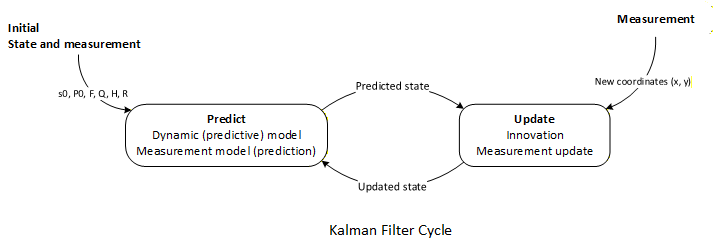

The Kalman filter formulation and intuition in this notebook build on several publicly available resources on tracking and state estimation (see [References](#references)):
- The multiple-object tracking implementation and code structure are inspired by Nick Nair’s open-source project on Kalman-based MOT [NickNair/MOT-KF].  
- The intuitive explanation of how the Kalman filter combines predictions and measurements follows the picture-based walkthrough by Bzarg [Bzarg].  
- The constant-velocity 2D motion model and update equations are consistent with the derivation in the Cookie Robotics tutorial [CookieRobotics].  
- Additional intuition and “for dummies” style explanations are adapted from Bilgin Esme’s notes [BilginEsme] and TheKalmanFilter.com [TheKalmanFilter].  
- The multi-target examples and notation partially follow KalmanFilter.net’s multi-example page [KalmanFilterNet].  
- The linear-Gaussian formulation and slides for computer vision applications are aligned with the RWTH Aachen lecture notes on Kalman filtering [RWTH-CV2].  
- The Python API design and some implementation details are consistent with the FilterPy KalmanFilter documentation and examples [FilterPy].  
- For general background and notation, we also refer to the Wikipedia article on the Kalman filter [WikipediaKF].


## Theory and Motion Model

### System model and initialization

#### Initial conditions

To run the Kalman filter, we must specify an initial state estimate and its error covariance [[WelchBishop], [KalmanFilterNet]]:

$$
s_{0|0} \in \mathbb{R}^n, \qquad P_{0|0} \in \mathbb{R}^{n\times n},
$$

where $n = 4$ for the CV model and $n = 6$ for the CA model.

We initialise the state from the first measurement, setting unknown quantities to zero [BilginEsme]:

$$
s_{0|0} =
\begin{bmatrix}
x_0^{\text{meas}} \\ y_0^{\text{meas}} \\ 0 \\ \vdots \\ 0
\end{bmatrix} \in \mathbb{R}^n
$$

We initialise $P_{0|0}$ with position variance equal to the GPS noise ($\sigma_r^2$). and large variance for velocity and acceleration — we simply don't know them [[KalmanFilterNet], Ch. 3].

#### Error covariance matrix P

$P_{k|k}$ is the covariance of the estimation error [[WelchBishop], [WikipediaKF]]:

$$
\varepsilon_k = s_k - s_{k|k}, \qquad
P_{k|k} = \mathbb{E}[\varepsilon_k \varepsilon_k^\top] \in \mathbb{R}^{n \times n}.
$$

A large $P$ means high uncertainty; a small $P$ means the filter is confident.
$P$ drives the Kalman gain — the larger $P$, the more the filter trusts the
measurement over the model.

During the algorithm $P$ evolves in two opposite directions:

- **Prediction** — $P$ grows via process noise $Q$
- **Update** — $P$ shrinks as the new measurement reduces uncertainty

For the initial covariance we choose [[KalmanFilterNet]]:

$$
P_{0|0} = \operatorname{diag}\bigl(\sigma_r^2,\, \sigma_r^2,\, \sigma_{v}^2,\, \sigma_{v}^2,\, \sigma_{a}^2,\, \sigma_{a}^2\bigr)
$$

where $\sigma_r^2 \approx 7.5^2$ m² matches the GPS noise estimated from raw data,
and $\sigma_{v}^2,\, \sigma_{a}^2 \gg \sigma_r^2$ — we have no prior knowledge
of velocity or acceleration. This produces a high initial Kalman gain, so the
filter converges quickly to the real trajectory in the first few steps.

The effect of a wrong $P_{0|0}$ disappears after enough measurements,
provided $Q$ and $R$ are well specified [[WelchBishop]].

#### State vector and transition matrix
At each moment $k$ we describe the object with a state vector $s_k \in \mathbb{R}^n$, where $n = 4$ (CV) or $n = 6$ (CA).

Using classical kinematics for a small step $dt$ [[CookieRobotics], [RWTH-CV2], [WelchBishop]]:

$$
x_{k+1} = x_k + v_{x,k}\,dt + \tfrac{1}{2}a_{x,k}\,dt^2, \qquad
v_{x,k+1} = v_{x,k} + a_{x,k}\,dt
$$

and analogously for $y$. In the CV model, $a_{x,k} = a_{y,k} = 0$.

Both models share the same structure [[WikipediaKF], [WelchBishop]]:

$$
s_{k+1} = F(dt)\, s_k + B\,u_k + w_k, \qquad F(dt) \in \mathbb{R}^{n \times n}
$$

where $w_k$ models unknown disturbances and $B\,u_k$ is an optional control input ($B = \mathbf{0}$ in our GPS application [WelchBishop]).

The matrix $F(dt)$ is built directly from the kinematic equations above. 
For the CV model the non-trivial entries are $F_{03} = F_{13} = dt$;
for CA additionally $F_{04} = F_{15} = \tfrac{1}{2}dt^2$ and
$F_{24} = F_{35} = dt$ — see `F_cv(dt)` and `F_ca(dt)`.

In [3]:
def F_cv(dt):
    """
    State transition matrix for Constant Velocity model.
    State: [x, y, vx, vy]
    """
    return np.array([
        [1, 0, dt, 0 ],
        [0, 1, 0,  dt],
        [0, 0, 1,  0 ],
        [0, 0, 0,  1 ]
    ], dtype=float)

def F_ca(dt):
    """
    State transition matrix for Constant Acceleration model.
    State: [x, y, vx, vy, ax, ay]
    """
    dt2 = 0.5 * dt**2
    return np.array([
        [1, 0, dt, 0,  dt2, 0  ],
        [0, 1, 0,  dt, 0,   dt2],
        [0, 0, 1,  0,  dt,  0  ],
        [0, 0, 0,  1,  0,   dt ],
        [0, 0, 0,  0,  1,   0  ],
        [0, 0, 0,  0,  0,   1  ]
    ], dtype=float)

#### Dynamic model and process noise Q
Real motion is never perfectly constant — a vehicle accelerates, brakes, and turns. These unpredictable deviations are modelled as process noise $w_k$ [[WelchBishop], [KalmanFilterNet]]:

$$
\mathbb{E}[w_k] = 0, \qquad \mathbb{E}[w_k w_k^\top] = Q.
$$

We assume noise acts only on acceleration — position and velocity inherit  uncertainty through $F$ [[KalmanFilterNet]]:

$$
Q_a = \sigma_a^2\,\operatorname{diag}(0,0,0,0,1,1), \qquad Q = F\,Q_a\,F^\top
$$

For CV the same applies with $Q_a = \sigma_a^2\,\operatorname{diag}(0,0,1,1)$.

The single parameter $\sigma_a^2$ controls the trade-off:

- **small** $\sigma_a^2$ — trust the motion model; smooth trajectory
- **large** $\sigma_a^2$ — allow erratic motion; trajectory follows measurements

See `Q_cv(dt, sigma_a)` and `Q_ca(dt, sigma_a)` in the implementation.

In [4]:
def Q_ca(dt, sigma_a=0.5):
    F = F_ca(dt)
    Qa = sigma_a**2 * np.diag([0, 0, 0, 0, 1, 1])
    return F @ Qa @ F.T

def Q_cv(dt, sigma_a=0.5):
    F = F_cv(dt)
    Qa = sigma_a**2 * np.diag([0, 0, 1, 1])
    return F @ Qa @ F.T

#### Measurement model   

GPS receivers measure only position — velocity and acceleration are not directly observed [RWTH-CV2, TheKalmanFilter] :

$$
z_k = H\, s_k + m_k, \qquad
\mathbb{E}[m_k] = 0, \quad \mathbb{E}[m_k m_k^\top] = R,
$$

where $H \in \mathbb{R}^{2 \times n}$ extracts position from the state:

$$
H = \begin{bmatrix} 1 & 0 & \cdots & 0 \\ 0 & 1 & \cdot & 0 \end{bmatrix}
$$

The measurement noise covariance $R$ is isotropic — equal uncertainty in $x$ and $y$ [TheKalmanFilter] :

$$
R = \sigma_r^2\, I_2
$$

In our GPS application, $\sigma_r \approx 7.5$ m, estimated from the step size distribution of the raw trajectories (see **Raw Data Validation**).

- **large** $\sigma_r^2$ — trust measurements less; filter relies more on the model
- **small** $\sigma_r^2$ — trust measurements more; filter follows GPS closely

In [5]:
def H_pos(n=4):
    """
    Measurement matrix — observes only position [x, y].
    Works for both CV (n=4) and CA (n=6).
    """
    H = np.zeros((2, n))
    H[0, 0] = 1
    H[1, 1] = 1
    return H

def R_pos(sigma_r=7.5):
    """
    Measurement noise covariance.
    sigma_r : float
        GPS positional noise standard deviation in metres.
        Estimated from raw data: sigma_r ≈ 7.5 m.
    """
    return sigma_r**2 * np.eye(2)


### Kalman Filter cycle
> see class FilterCalman.

#### Predict step
The predict step answers the question: *where should the object be now, before we look at the new measurement?* Without it, the filter would rely solely on noisy GPS fixes with no physical continuity between steps [[Bzarg], [BilginEsme]].

Given the current estimate $(s_{k|k}, P_{k|k})$, the filter predicts the next state before a new measurement arrives [[WelchBishop]]:

$$
s_{k+1|k} = F\,s_{k|k}, \qquad P_{k+1|k} = F\,P_{k|k}F^\top + Q.
$$

In our GPS application there is no control input — the vehicle is passively observed, so $B\,u_k = 0$ [[RWTH-CV2], [NickNair/MOT-KF]].

- $F\,s_{k|k}$ — where the model predicts the object will be
- $F\,P_{k|k}F^\top$ — how existing uncertainty propagates through $F$
- $Q$ — additional uncertainty from unmodelled manoeuvres

Since GPS sampling is irregular, $F(dt)$ and $Q(dt)$ are rebuilt at each step — see `KalmanFilter.predict(s, P, dt)`.

In practice, GPS fixes are recorded at irregular intervals — $dt$ varies between consecutive points. For this reason, $F(dt)$ and $Q(dt)$ are rebuilt at each prediction step rather than fixed at construction time. The `KalmanFilter` class accepts `F_builder(dt)` and `Q_builder(dt)` — callables that return the correct matrices for each time step.

#### Update step
##### Innovation
The innovation answers: *how surprised is the filter by the new measurement?* It is the difference between what the sensor reports and what the model predicted [[WelchBishop], [Bzarg]]:

$$
e_{k+1} = z_{k+1} - \hat{z}_{k+1|k}, \qquad \hat{z}_{k+1|k} = H\,s_{k+1|k}.
$$

If $e_{k+1} \approx 0$ — the model predicted well, little correction needed.  
If $e_{k+1}$ is large — the object deviated from the model, the measurement pulls the estimate strongly.

The innovation is also a diagnostic tool: for a well-tuned filter, $e_{k+1}$ should be zero-mean white noise [[RWTH-CV2], [FilterPy]]. We use this property later to validate the filter parameters on the GPS segments.

##### Kalman gain

The Kalman gain $K_{k+1}$ is the optimal weight between model and measurement
[[WelchBishop], [Bzarg], [KalmanFilterNet]]:

$$
K_{k+1} = P_{k+1|k} H^\top \bigl(H P_{k+1|k} H^\top + R\bigr)^{-1}.
$$

- large $P_{k+1|k}$, small $R$ → $K \to H^{-1}$ — trust the measurement
- small $P_{k+1|k}$, large $R$ → $K \to 0$ — trust the model

The denominator $S = H P_{k+1|k} H^\top + R$ is the total uncertainty in measurement space — model uncertainty projected by $H$ plus sensor noise $R$.
It is also used for innovation analysis [[FilterPy], [RWTH-CV2]].

The Kalman gain $K_k$ is exactly this “trust coefficient” – it determines how strongly the new measurement should pull the current prediction, so that the final estimate has the smallest possible uncertainty.

Implemented as part of `KalmanFilter.update(s, P, z)`.

##### State update

The predicted state is corrected by the innovation, weighted by the Kalman gain [[WelchBishop], [Bzarg]]:

$$
s_{k+1|k+1} = s_{k+1|k} + K_{k+1}\,e_{k+1}.
$$

$K_{k+1}\,e_{k+1}$ is the correction — it adjusts not only position but also velocity and acceleration through the structure of $K_{k+1}$ [[RWTH-CV2]].
A large innovation pulls the estimate strongly toward the measurement; 
a small innovation leaves it close to the prediction.


>>**Notation:** $s_{k+1|k}$ denotes the state estimate for moment $k+1$ using information up to $k$ only — the *predicted* state before the new measurement.
$s_{k+1|k+1}$ is the *updated* state after incorporating the measurement at $k+1$ [[WelchBishop]].


##### Covariance update

After incorporating the measurement, uncertainty decreases [[WelchBishop], [Bzarg]]:

$$
P_{k+1|k+1} = \left(I_n - K_{k+1} H \right) P_{k+1|k}.
$$

$K_{k+1} H$ represents the fraction of prediction uncertainty removed by the measurement. The updated $P_{k+1|k+1} \leq P_{k+1|k}$ — the filter is more confident after the update, especially in position, and indirectly in velocity and acceleration through $K_{k+1}$ [[RWTH-CV2]].

This closes the predict → update cycle. The updated $(s_{k+1|k+1}, P_{k+1|k+1})$ become the input to the next predict step.


## Dataset — Microsoft GeoLife GPS Trajectories

### Source and collection

The **GeoLife** dataset was collected by Microsoft Research Asia between April 2007 and August 2012 [[Zheng et al., 2009]](https://www.microsoft.com/en-us/download/details.aspx?id=52367). 182 users recorded their outdoor movements in and around Beijing, China, using GPS loggers and GPS-enabled phones over a period of more than five years.

> **Download:** https://www.microsoft.com/en-us/download/details.aspx?id=52367

> [User Guide-1.3 and Microsoft Research License Agreement](data/raw_data_trajectories/geolife_1.3/geolife_trajectories/User%20Guide-1.3.pdf)


The full dataset contains **17,621 trajectories**, covering a total distance of approximately 1.2 million kilometres and over 48,000 hours of movement. **91% of trajectories** are recorded at high density — one point every **1–5 seconds** or every 5–10 metres.

The dataset is organised by user:
```
Data/
├── 010/
│   ├── labels.txt          ← transport mode per time interval
│   └── Trajectory/         ← 161 .plt files
│       └── ...
├── 020/
├── labels.txt          ← transport mode per time interval
│   └── Trajectory/         ← 151 .plt files
│       └── ...
└── ── 021/
├── labels.txt          ← transport mode per time interval
    └── Trajectory/         ← 8 .plt files
        └── ...
```

Total: **320 trajectory files** across 3 users.

---

### File format

Each `.plt` file is a plain-text GPS log. The first 6 lines are a fixed header and are skipped. From line 7 onward:

| Column | Field | Unit |
|--------|-------|------|
| 0 | Latitude | degrees WGS-84 |
| 1 | Longitude | degrees WGS-84 |
| 2 | Unused | — |
| 3 | Altitude | feet |
| 4 | Days since 1899-12-30 | float |
| 5 | Date | YYYY-MM-DD |
| 6 | Time | HH:MM:SS |

Transport mode labels are stored in a separate `labels.txt` per user:
```
Start Time          End Time            Transportation Mode
2008/06/26 11:11:07 2008/06/26 11:31:08 taxi
2008/06/26 11:31:08 2008/06/26 12:03:00 taxi
2008/06/28 08:55:00 2008/06/28 09:14:00 car
...
```

---

### Data Loading

Each `.plt` file is read with `pandas.read_csv()`, skipping the 6-line header. Columns `date` and `time` are combined into a single `ts` (timestamp) column. Only `lat`, `lon` and `ts` are retained — altitude and the unused field are dropped.

The example below shows a single file from user 010: **1,116 points** recorded over **44 minutes** on 2007-08-04.

In [6]:
def read_plt(path):
    """
    Read a GeoLife .plt file into a DataFrame.

    The first 6 lines are a fixed header and are skipped.

    Parameters
    ----------
    path : str
        Path to the .plt file.

    Returns
    -------
    df : DataFrame
        Columns: lat, lon, ts (timestamp).
    """
    df = pd.read_csv(
        path,
        skiprows=6,
        header=None,
        names=['lat', 'lon', '_', 'alt', 'days', 'date', 'time']
    )
    df['ts'] = pd.to_datetime(df['date'] + ' ' + df['time'])
    return df[['lat', 'lon', 'ts']].reset_index(drop=True)

In [7]:
# Quick look at a single .plt file
sample_path = 'data/raw_data_trajectories/geolife_1.3/geolife_trajectories/data/010/Trajectory/20070804033032.plt'

df_sample = read_plt(sample_path)

print(f"Points:    {len(df_sample)}")
print(f"From:      {df_sample['ts'].min()}")
print(f"To:        {df_sample['ts'].max()}")
print(f"Duration:  {df_sample['ts'].max() - df_sample['ts'].min()}")
print()
df_sample.head()

Points:    1116
From:      2007-08-04 03:30:32
To:        2007-08-04 04:14:46
Duration:  0 days 00:44:14



,lat,lon,ts
0,39.921712,116.472343,2007-08-04 03:30:32
1,39.921705,116.472343,2007-08-04 03:30:33
2,39.921695,116.472345,2007-08-04 03:30:34
3,39.921683,116.472342,2007-08-04 03:30:35
4,39.921672,116.472342,2007-08-04 03:30:36


### Label Matching

Each user's "labels.txt" maps time intervals to transport modes. `read_labels()` parses the file into a DataFrame with `start`, `end` and `mode` columns. 

* `compute_dt()` computes the time difference between consecutive GPS points in seconds and returns a boolean mask `valid` — `True` for steps within `max_dt` seconds. This is used later to detect GPS signal loss.
* `match_segments()` iterates over all labelled intervals, extracts the GPS points that fall within each interval, and keeps only segments with at least `min_points` points.

In [8]:
def read_labels(path):
    """
    Read a GeoLife labels.txt file.

    Parameters
    ----------
    path : str
        Path to labels.txt

    Returns
    -------
    df : DataFrame
        Columns: start, end, mode
    """
    df = pd.read_csv(path, sep='\t')
    df.columns = ['start', 'end', 'mode']
    df['start'] = pd.to_datetime(df['start'])
    df['end']   = pd.to_datetime(df['end'])
    return df

def compute_dt(df, max_dt=30.0):
    """
    Compute time differences between consecutive GPS fixes in seconds.
    Clips dt to [0.1, max_dt] to avoid division by zero and GPS jumps.
    """
    dt = np.diff(df['ts'].values).astype('timedelta64[s]').astype(float)
    dt = np.clip(dt, 0.1, max_dt)
    valid = dt <= max_dt
    return dt, valid


def match_segments(traj, labels, modes=('car', 'taxi'), min_points=30):
    """
    Extract trajectory segments that fall within labelled time intervals.

    Parameters
    ----------
    traj       : DataFrame   output of read_plt()
    labels     : DataFrame   output of read_labels()
    modes      : tuple       transport modes to keep
    min_points : int         minimum points per segment

    Returns
    -------
    segments : list of dict
        Each dict has keys: mode, df (subset of traj)
    """
    segments = []
    for _, row in labels[labels['mode'].isin(modes)].iterrows():
        mask = (traj['ts'] >= row['start']) & (traj['ts'] <= row['end'])
        seg  = traj[mask].reset_index(drop=True)
        if len(seg) >= min_points:
            segments.append({'mode': row['mode'], 'df': seg})
    return segments

In [9]:
labels_path = 'data/raw_data_trajectories/geolife_1.3/geolife_trajectories/data/010/labels.txt'
labels      = read_labels(labels_path)

print(labels['mode'].value_counts())

mode
walk        153
train       100
taxi         96
subway       47
bus          35
airplane      2
car           1
Name: count, dtype: int64


### Segment Loading and Outlier Filtering

The raw GPS signal contains two types of variation:

1. **Real movement** — the vehicle actually changing position between fixes.
2. **Measurement noise** — random positional error from the GPS receiver, typically **4–10 metres** for consumer-grade devices.

These two are mixed together in the raw signal and cannot be separated by simply looking at a single point. The Kalman filter separates them by maintaining a **motion model** — it predicts where the vehicle *should* be based on its previous state, and then blends that prediction with the noisy GPS fix using two key parameters:
- **σ_r** (measurement noise) — how much we trust the GPS reading. Set from the step size distribution: σ ≈ 7.5 m.
- **σ_q** (process noise) — how much we allow the motion model to deviate. Reflects real acceleration — how aggressively the vehicle can change speed or direction between fixes.

The step size distribution (right panel) gives us a direct estimate of σ_r before we run a single line of Kalman code.

The GeoLife dataset stores positions as WGS-84 latitude/longitude degrees. The Kalman filter works in Cartesian space (metres) — distances, velocities and accelerations are physically meaningful only in a metric coordinate system.

`to_xy()` projects each GPS fix onto a local flat-earth plane using the
**equirectangular approximation**:

$$x = R \cdot \Delta\lambda \cdot \cos(\phi_0)$$
$$y = R \cdot \Delta\phi$$

where $\phi_0$ is the latitude of the first point (origin), $\Delta\phi$ and $\Delta\lambda$ are the differences in latitude and longitude in radians, and $R = 6{,}371{,}000$ m is the Earth's mean radius.

The approximation is accurate to within ~0.1% for trajectories shorter than 100 km — well within the range of urban car and taxi trips.

> Source: [Movable Type Scripts — Lat/Lon calculations](https://www.movable-type.co.uk/scripts/latlong.html)

In [10]:
# Common origin — start point of segment
# https://geohack.toolforge.org/geohack.php?pagename=Beijing&params=39_54_24_N_116_23_51_E_type:adm1st_region:CN-11
BEIJING_ORIGIN = (39.906667, 116.3975)

def to_xy(df, start_point=BEIJING_ORIGIN):
    """
    Convert lat/lon coordinates to local Cartesian (metres).

    Uses the first point as the origin. The approximation is
    valid for short trajectories (< ~100 km).

    Conversion factors:
        1 degree latitude  ≈ 111,320 m  (constant)
        1 degree longitude ≈ 111,320 * cos(lat) m  (varies with latitude)

    Source: https://en.wikipedia.org/wiki/Geographic_coordinate_system#Length_of_a_degree
    Source: https://www.movable-type.co.uk/scripts/latlong.html

    Parameters
    ----------
    df : DataFrame
        Output of read_plt() or a segment slice of it.
        Must contain columns: lat, lon.

    Returns
    -------
    x : ndarray   east-west displacement in metres
    y : ndarray   north-south displacement in metres
    """
    lat0, lon0 = start_point
    
    # Equirectangular approximation
    R = 6_371_000  # Earth's radius in metres
    x = R * np.radians(df['lon'] - lon0) * np.cos(np.radians(lat0))
    y = R * np.radians(df['lat'] - lat0)

    return x.values, y.values

In [11]:
def load_all_segments(trajectory_dir, labels_path, modes=('car', 'taxi'), min_points=30):
    labels    = read_labels(labels_path)
    plt_files = glob.glob(os.path.join(trajectory_dir, '*.plt'))

    segments = []
    for plt_path in plt_files:
        traj = read_plt(plt_path)
        segs = match_segments(traj, labels, modes, min_points)
        for s in segs:
            s['file'] = os.path.basename(plt_path) 
        segments.extend(segs)
       
    return segments

def has_outlier(seg, max_dt=10.0):
    dt, valid = compute_dt(seg['df'])
    return not valid.all()

In [12]:
dir_trj = "data/raw_data_trajectories/geolife_1.3/geolife_trajectories/data/"
users = [
    {
        "trajectory_dir": f"{dir_trj}/010/Trajectory/",
        "labels_path":    f"{dir_trj}/010/labels.txt"
    },
    {
        "trajectory_dir": f"{dir_trj}/020/Trajectory/",
        "labels_path":    f"{dir_trj}/020/labels.txt"
    },
    {
        "trajectory_dir": f"{dir_trj}/021/Trajectory/",
        "labels_path":    f"{dir_trj}/021/labels.txt"
    },
]

all_segments = []
for user in users:
    segs = load_all_segments(
        trajectory_dir = user['trajectory_dir'],
        labels_path    = user['labels_path']
    )
    all_segments.extend(segs)

print(f"Total segments: {len(all_segments)}")
print(f"Car:  {sum(1 for s in all_segments if s['mode'] == 'car')}")
print(f"Taxi: {sum(1 for s in all_segments if s['mode'] == 'taxi')}")

print(f"Total segments: {len(all_segments)}")

Total segments: 103
Car:  11
Taxi: 92
Total segments: 103


In [13]:
for s in all_segments:
    if s['mode'] == 'car':
        x, y = to_xy(s['df'])
        steps = np.sqrt(np.diff(x)**2 + np.diff(y)**2)
        print(f"{s['file']}  n={len(s['df'])}  max_step={steps.max():.1f}m")

20080927114213.plt  n=2372  max_step=106.9m
20110911000506.plt  n=4213  max_step=2785.8m
20070429222711.plt  n=208  max_step=50422.8m
20070429222711.plt  n=78  max_step=23359.6m
20070429222711.plt  n=253  max_step=64509.2m
20070501010311.plt  n=53  max_step=13662.2m
20070501010311.plt  n=75  max_step=22702.0m
20070501010311.plt  n=118  max_step=2158.7m
20070502001318.plt  n=85  max_step=82468.3m
20070502013107.plt  n=98  max_step=1033.7m
20070502013107.plt  n=44  max_step=1047.8m


In [14]:
def has_gps_jump(seg, max_step=500):
    x, y  = to_xy(seg['df'])
    steps = np.sqrt(np.diff(x)**2 + np.diff(y)**2)
    return steps.max() > max_step

all_segments = [s for s in all_segments if not has_gps_jump(s)]

print(f"Total segments: {len(all_segments)}")
print(f"Car:  {sum(1 for s in all_segments if s['mode'] == 'car')}")
print(f"Taxi: {sum(1 for s in all_segments if s['mode'] == 'taxi')}")

Total segments: 91
Car:  1
Taxi: 90


In [15]:
def plot_raw_trajectory(seg, title=None):
    """
    Plot a single raw GPS trajectory segment.
    Left panel  : 2D path in local Cartesian coordinates (km).
    Right panel : distribution of step sizes between consecutive GPS fixes.
    """
    x, y  = to_xy(seg['df'])
    steps = np.sqrt(np.diff(x)**2 + np.diff(y)**2)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # --- Left: trajectory ---
    axes[0].plot(x/1000, y/1000, 'o-', color='crimson',
                 ms=2, lw=1, alpha=0.7)
    axes[0].set_xlabel('X (km)')
    axes[0].set_ylabel('Y (km)')
    axes[0].set_title(f"Raw GPS — {seg['mode']} (n={len(x)})")
    axes[0].grid(True)

    # --- Right: step size distribution ---
    axes[1].hist(steps, bins=30, color='crimson', alpha=0.8)
    axes[1].axvline(steps.mean(), color='white', lw=2, ls='--',
                    label=f'mean={steps.mean():.1f} m')
    axes[1].set_xlabel('Step size (m)')
    axes[1].set_ylabel('Count')
    axes[1].set_title(f"Step distribution  σ={steps.std():.2f} m")
    axes[1].legend()
    axes[1].grid(True)

    plt.suptitle(title or seg['file'])
    plt.tight_layout()
    plt.show()

Each plot shows two panels:

- **Left** — the 2D trajectory in local Cartesian coordinates. The origin (0, 0) is the first GPS fix of the segment. Jitter on straight sections is visible GPS noise.
- **Right** — the distribution of step sizes between consecutive fixes (1-second intervals).

The dashed white line marks the mean step size; σ is the standard deviation — our empirical estimate of GPS positional noise.

### Raw Data Validation

Before applying the Kalman filter, we visually inspect two representative segments: the longest taxi trajectory and the only car segment.

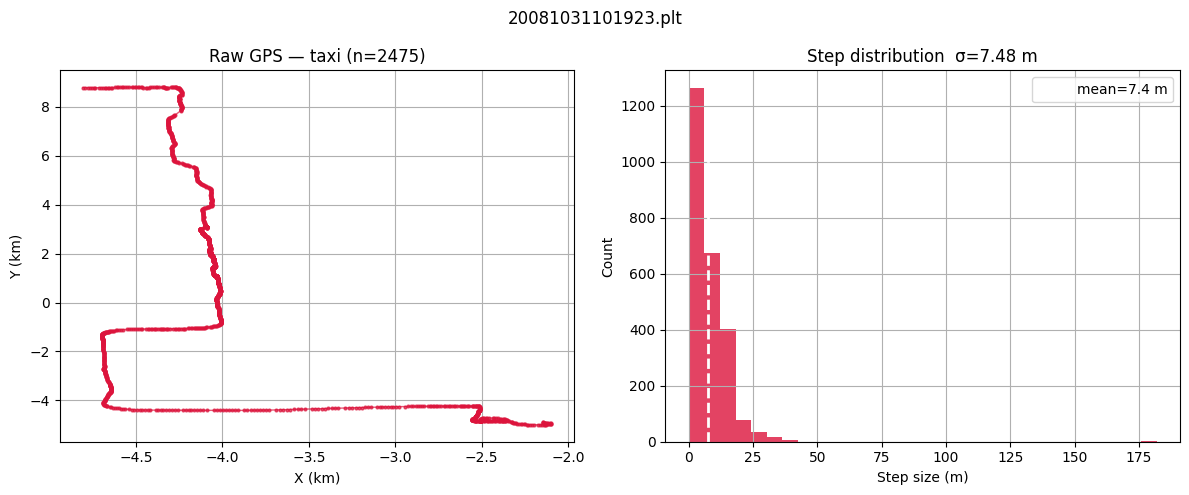

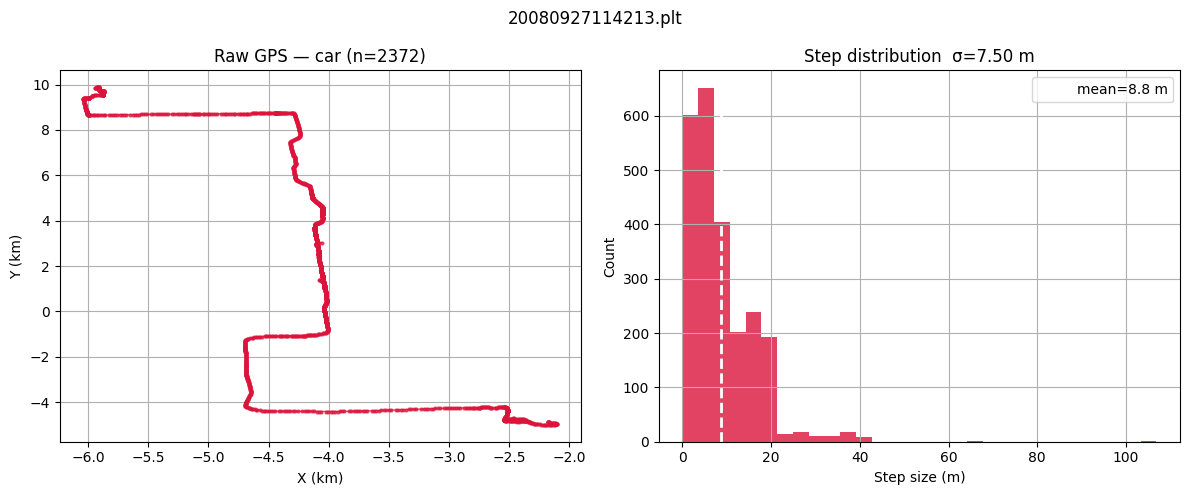

In [16]:
# Raw visualization — longest taxi segment
# Longest taxi segment
taxi_seg = max(
    (s for s in all_segments if s['mode'] == 'taxi'),
    key=lambda s: len(s['df'])
)
plot_raw_trajectory(taxi_seg)

# Longest car segment
car_seg = max(
    (s for s in all_segments if s['mode'] == 'car'),
    key=lambda s: len(s['df'])
)
plot_raw_trajectory(car_seg)

Both car and taxi segments show a GPS positional noise of approximately **7.5 metres** (measured as the standard deviation of step sizes). This is consistent with consumer-grade GPS accuracy under urban conditions (Beijing, 2007–2008).

The trajectory plot reveals the characteristic jitter of consumer GPS — the path appears jagged even on straight road sections. This is exactly what the Kalman filter is designed to smooth.

> **TODO:** Extend analysis to all transport modes (walk, bike, bus, subway, train).
> Each mode has distinct motion characteristics and may benefit from different
> Kalman parameters (σ_r, σ_q).

## Realization 

### Class KalmanFilter

File _src/kalman_tracker.py_ defines a generic 2D Kalman class _KalmanFilter_, with a built-in logger for all key quantities.
> [Open kalman_tracker.py](src/kalman_tracker.py)

**General idea:**

The KalmanFilter class implements the standard linear Kalman filter for a state $s_k \in \mathbb{R}^n$ and a measurement $z_k \in \mathbb{R}^m$, with the following matrices:

- $F$ – state transition matrix
- $Q$ – process noise covariance
- $H$ – measurement matrix
- $R$ – measurement noise covariance
- $B$ – control input matrix (optional, default `None`)

> Optionally, it accepts a class *StateLogger*, which records at each step: states $s$, covariances $P$, gain $K$, measurements $z$, predicted measurements $\hat{z}$, and innovations $e$.
> [Open state_logger.py](src/state_logger.py)

For variable time-step applications (e.g. GPS), `F_builder(dt)` and `Q_builder(dt)` can be supplied — the matrices are then rebuilt at each prediction step.

**Methods:**

_`__init__(self, F, Q, H, R, logger=None, F_builder=None, Q_builder=None, B=None)`_  
Stores matrices and optional logger. No logic, just configuration.

_`predict(self, s_k_k, P_k_k, dt=None, u=None)`_  
Implements the prediction step:
$$s_{k+1|k} = F s_{k|k} + B u_k \qquad P_{k+1|k} = F P_{k|k} F^\top + Q$$
If `dt` and `F_builder` are provided, $F$ and $Q$ are rebuilt for the current time step.  
Returns $(s_{k+1|k},\ P_{k+1|k})$.

_`update(self, s_k1_k, P_k1_k, z_k1)`_  
Combines innovation, Kalman gain, state update and covariance update in one call:
$$e = z_{k+1} - H s_{k+1|k} \qquad K = P_{k+1|k} H^\top S^{-1}$$
$$s_{k+1|k+1} = s_{k+1|k} + K e \qquad P_{k+1|k+1} = (I - KH)\, P_{k+1|k}$$
Logs $s, P, K, z, \hat{z}, e$ if a logger is attached.  
Returns $(s_{k+1|k+1},\ P_{k+1|k+1})$.

_`reset()`_  
Clears the logger history. Use between segments when reusing the same instance.

In [17]:
def run_kf(seg, F0, Q0, H, R, F_builder, Q_builder, n, sigma_r=7.5):
    df = seg['df']
    x, y      = to_xy(df)
    dt_arr, _ = compute_dt(df)

    s = np.zeros((n, 1))
    s[0, 0] = x[0]
    s[1, 0] = y[0]
    P = np.diag([sigma_r**2, sigma_r**2] + [1000.] * (n - 2))

    logger = StateLogger(["s", "z", "e", "K"])
    kf     = KalmanFilter(F0, Q0, H, R, logger,
                          F_builder=F_builder,
                          Q_builder=Q_builder)

    for k in range(1, len(x)):
        z    = np.array([[x[k]], [y[k]]])
        dt_k = dt_arr[k-1]
        s, P = kf.predict(s, P, dt=dt_k)
        s, P = kf.update(s, P, z)

    return logger

### GPS Kalman Filter

Acceleration RMS

The **Root Mean Square (RMS)** of acceleration is our primary smoothness metric:

$$
\text{acc\_rms} = \sqrt{\frac{1}{N}\sum_{k=1}^{N} \left(a_{x,k}^2 + a_{y,k}^2\right)}
$$

where $a_{x,k}$, $a_{y,k}$ are computed numerically from consecutive position estimates:

$$
a_{x,k} = \frac{v_{x,k+1} - v_{x,k}}{dt}, \qquad v_{x,k} = \frac{x_{k+1} - x_k}{dt}
$$

**Why acceleration RMS?**

Raw GPS noise creates artificial velocity jumps between consecutive fixes —
even on a straight road the reported positions jitter by ~7.5 m, producing
spurious accelerations of 5–20 m/s². Real urban driving rarely exceeds 3 m/s².

A lower acceleration RMS means a smoother, more physically consistent trajectory.
It is a proxy for how much GPS noise remains after filtering — without requiring
ground truth [[FilterPy]].

#### CV model (4D)

In this section we apply the Constant Velocity Kalman filter to the car and taxi segments. We set the following parameters:

- $\sigma_r = 7.5$ m — estimated from the raw GPS step distribution
- $\sigma_a = 0.5$ m/s² — assumed process noise for urban driving

We evaluate the filter using two metrics:

- **Acceleration RMS** — measures trajectory smoothness; lower means less jitter
- **Innovation RSE** (median and p95) — measures prediction accuracy in metres

Additionally we inspect the innovation distribution to verify the filter is unbiased and well-calibrated.

In [18]:
def run_kf_cv(seg, sigma_r=7.5, sigma_a=0.5):
    return run_kf(seg,
                  F0       = F_cv(1.0),
                  Q0       = Q_cv(1.0, sigma_a),
                  H        = H_pos(n=4),
                  R        = R_pos(sigma_r),
                  F_builder= F_cv,
                  Q_builder= lambda dt: Q_cv(dt, sigma_a),
                  n        = 4,
                  sigma_r  = sigma_r)

In [19]:
def extract_xy_from_history(points_hist):
    points_arr = points_hist.squeeze()
    x = points_arr[:, 0]
    y = points_arr[:, 1]

    return x, y

In [20]:
def extract_state_components(s_hist):
    """
    Extract state components from logger history.
    Works for both CV (n=4) and CA (n=6).

    Returns
    -------
    x, y, vx, vy          for n=4
    x, y, vx, vy, ax, ay  for n=6
    """
    arr = np.squeeze(s_hist)  # (N, n)
    n   = arr.shape[1]

    x  = arr[:, 0]
    y  = arr[:, 1]
    vx = arr[:, 2]
    vy = arr[:, 3]

    if n == 6:
        ax = arr[:, 4]
        ay = arr[:, 5]
        return x, y, vx, vy, ax, ay

    return x, y, vx, vy


In [21]:
def compute_metrics(seg, logger, model='cv'):
    x_raw, y_raw = to_xy(seg['df'])
    dt_arr, _    = compute_dt(seg['df'])

    s, e       = logger.get_stat(["s", "e"])
    kx, ky = extract_xy_from_history(s)
    e          = np.squeeze(e)
    e_norm     = np.sqrt(e[:, 0]**2 + e[:, 1]**2)

    return {
        'acc_raw':    acceleration_rms(x_raw, y_raw, dt_arr),
        'acc_kf':     acceleration_rms(kx, ky, dt_arr[1:]),
        'rse_median': np.median(e_norm),
        'rse_p95':    np.percentile(e_norm, 95),
        'e':          e,
        'model':      model,
    }

In [22]:
def acceleration_rms(x, y, dt_arr):
    """
    RMS of acceleration magnitude — measure of trajectory smoothness.
    Lower is smoother.
    """
    vx = np.diff(x) / dt_arr
    vy = np.diff(y) / dt_arr
    ax = np.diff(vx) / dt_arr[1:]
    ay = np.diff(vy) / dt_arr[1:]
    return np.sqrt(np.mean(ax**2 + ay**2))

In [23]:
def plot_trajectory(x_meas, y_meas, x_est, y_est,
                    x_true=None, y_true=None,
                    title='', ax=None,
                    zoom=None):
    """
    zoom : tuple (x_min, x_max, y_min, y_max) in km, optional
    """
    show = ax is None
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))

    if x_true is not None and y_true is not None:
        ax.plot(x_true/1000, y_true/1000, 'g-', lw=1, label='true trajectory')
    ax.plot(x_meas/1000, y_meas/1000, 'o-', color='crimson',
            ms=2, lw=1, alpha=0.7, label='raw GPS')
    ax.plot(x_est/1000, y_est/1000, 'b-', lw=1.5, label='KF estimate')
    ax.set_xlabel('X (km)'); ax.set_ylabel('Y (km)')
    ax.grid(True); ax.legend()
    ax.set_title(title)

    if zoom:
        ax.set_xlim(zoom[0], zoom[1])
        ax.set_ylim(zoom[2], zoom[3])

    if show:
        plt.show()

In [24]:
car_cv_logger  = run_kf_cv(car_seg)
taxi_cv_logger = run_kf_cv(taxi_seg)

m_car  = compute_metrics(car_seg,  car_cv_logger,  model='cv')
m_taxi = compute_metrics(taxi_seg, taxi_cv_logger, model='cv')

print(f"{'':>6} {'acc_raw':>10} {'acc_kf':>10} {'imp%':>8} {'rse_med':>10} {'rse_p95':>10}")
print("-" * 58)
for name, m in [('car', m_car), ('taxi', m_taxi)]:
    imp = (1 - m['acc_kf'] / m['acc_raw']) * 100
    print(f"{name:>6} {m['acc_raw']:10.3f} {m['acc_kf']:10.3f} "
          f"{imp:8.1f}% {m['rse_median']:10.3f} {m['rse_p95']:10.3f}")

          acc_raw     acc_kf     imp%    rse_med    rse_p95
----------------------------------------------------------
   car      2.085      0.968     53.6%      4.766     19.399
  taxi      1.628      0.953     41.4%      4.107     16.328


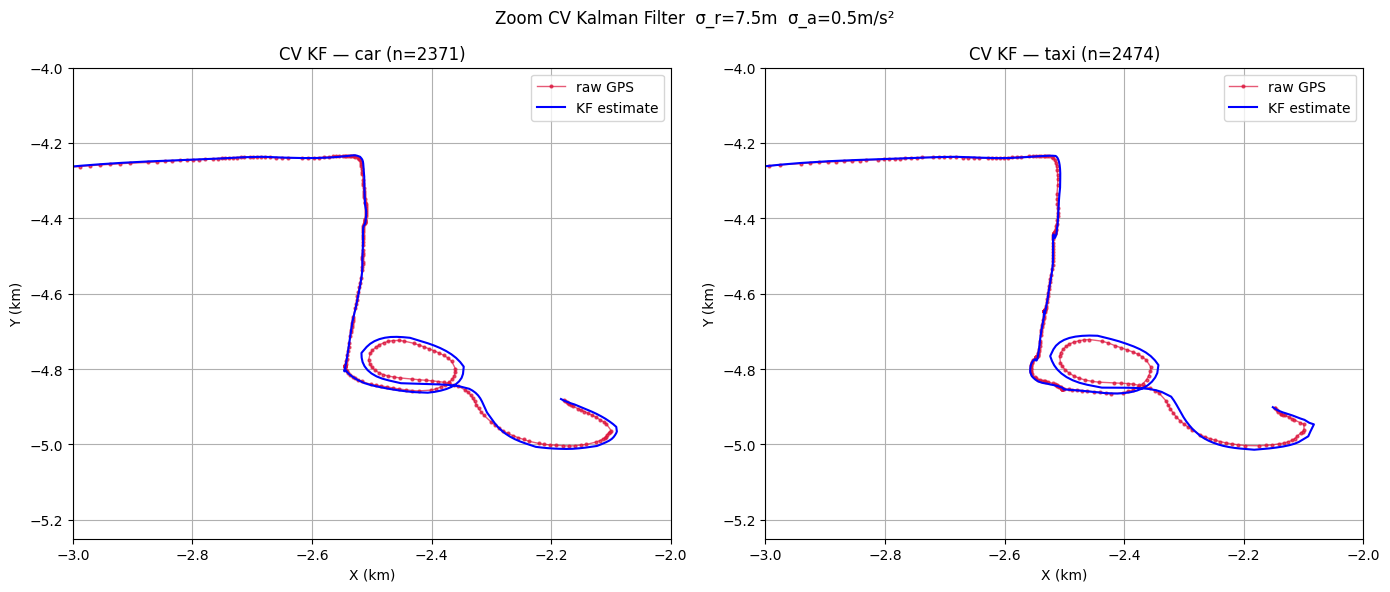

<Figure size 640x480 with 0 Axes>

In [25]:
car_s_cv, car_z_cv   = car_cv_logger.get_stat(["s", "z"])
car_kx_cv, car_ky_cv = extract_xy_from_history(car_s_cv)
car_x_meas_cv, car_y_meas_cv = extract_xy_from_history(car_z_cv)

taxi_s_cv, taxi_z_cv = taxi_cv_logger.get_stat(["s", "z"])
taxi_kx_cv, taxi_ky_cv = extract_xy_from_history(taxi_s_cv)
taxi_x_meas_cv, taxi_y_meas_cv = extract_xy_from_history(taxi_z_cv)

fig_cv, axes_cv = plt.subplots(1, 2, figsize=(14, 6))

zoom = (-3.0,-2.0,-5.25, -4.0)

plot_trajectory(car_x_meas_cv,  car_y_meas_cv,  car_kx_cv,  car_ky_cv,
                title=f"CV KF — {car_seg['mode']} (n={len(car_x_meas_cv)})",
                ax=axes_cv[0],  zoom = zoom)
plot_trajectory(taxi_x_meas_cv, taxi_y_meas_cv, taxi_kx_cv, taxi_ky_cv,
                title=f"CV KF — {taxi_seg['mode']} (n={len(taxi_x_meas_cv)})",
                ax=axes_cv[1],  zoom = zoom)

plt.suptitle("Zoom CV Kalman Filter  σ_r=7.5m  σ_a=0.5m/s²")
plt.tight_layout()
plt.show()


plt.suptitle("Zoom CV Kalman Filter  σ_r=7.5m  σ_a=0.5m/s²")
plt.tight_layout()
plt.show()

**CV model results — car vs taxi:**

Both segments show significant improvement in trajectory smoothness:

- **Car** — acceleration RMS drops from 2.08 to 0.97 m/s² (**53.6% reduction**).
  The larger improvement reflects more aggressive dynamics — turns and stops
  that the CV model smooths out effectively.

- **Taxi** — 41.4% reduction, from 1.63 to 0.95 m/s². Lower raw RMS suggests
  slightly smoother driving compared to the car segment.

**Prediction accuracy (innovation RSE):**

- Median RSE of **4.1–4.8 m** for both — well within the GPS noise level of σ_r = 7.5 m. The filter predicts position to roughly half the sensor noise. ✓
- p95 of **16–19 m** — 95% of predictions are within 19 m of the measurement. The remaining 5% correspond to sharp turns and stops where the constant-velocity assumption breaks down.

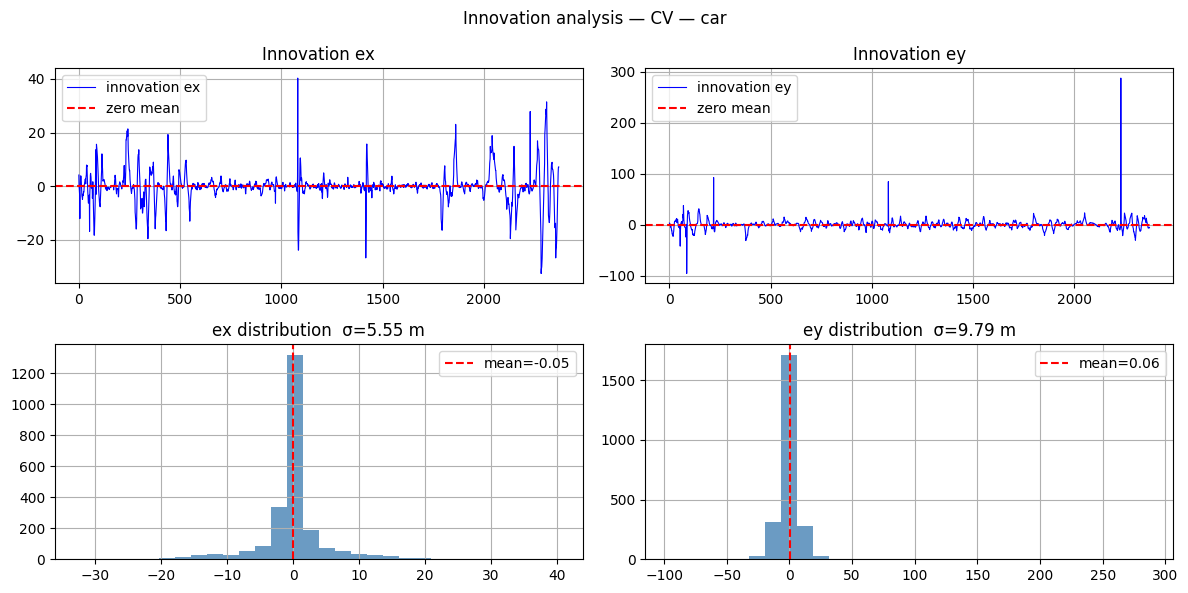

ex: mean=-0.051  std=5.551  min=-32.499  max=40.281
ey: mean=0.063  std=9.792  min=-95.814  max=287.330


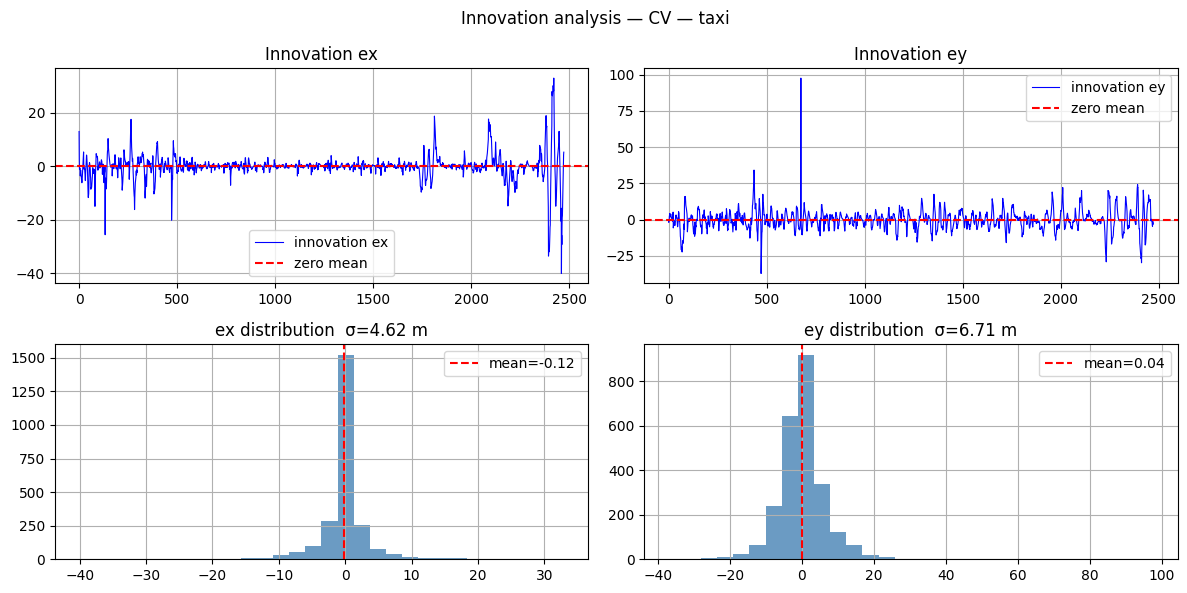

ex: mean=-0.117  std=4.623  min=-40.093  max=32.925
ey: mean=0.038  std=6.706  min=-37.078  max=97.687


In [26]:
def plot_innovations(seg, logger, model_name='CV'):
    e = np.squeeze(logger.get_stat("e"))
    ex, ey = e[:, 0], e[:, 1]

    fig, axes = plt.subplots(2, 2, figsize=(12, 6))

    axes[0, 0].plot(ex, 'b-', lw=0.8, label='innovation ex')
    axes[0, 0].axhline(0, color='r', ls='--', label='zero mean')
    axes[0, 0].set_title('Innovation ex'); axes[0, 0].legend(); axes[0, 0].grid(True)

    axes[0, 1].plot(ey, 'b-', lw=0.8, label='innovation ey')
    axes[0, 1].axhline(0, color='r', ls='--', label='zero mean')
    axes[0, 1].set_title('Innovation ey'); axes[0, 1].legend(); axes[0, 1].grid(True)

    axes[1, 0].hist(ex, bins=30, color='steelblue', alpha=0.8)
    axes[1, 0].axvline(ex.mean(), color='r', ls='--', label=f'mean={ex.mean():.2f}')
    axes[1, 0].set_title(f'ex distribution  σ={ex.std():.2f} m')
    axes[1, 0].legend(); axes[1, 0].grid(True)

    axes[1, 1].hist(ey, bins=30, color='steelblue', alpha=0.8)
    axes[1, 1].axvline(ey.mean(), color='r', ls='--', label=f'mean={ey.mean():.2f}')
    axes[1, 1].set_title(f'ey distribution  σ={ey.std():.2f} m')
    axes[1, 1].legend(); axes[1, 1].grid(True)

    plt.suptitle(f'Innovation analysis — {model_name} — {seg["mode"]}')
    plt.tight_layout()
    plt.show()

    print(f"ex: mean={ex.mean():.3f}  std={ex.std():.3f}  min={ex.min():.3f}  max={ex.max():.3f}")
    print(f"ey: mean={ey.mean():.3f}  std={ey.std():.3f}  min={ey.min():.3f}  max={ey.max():.3f}")

plot_innovations(car_seg, car_cv_logger,  model_name='CV')
plot_innovations(taxi_seg, taxi_cv_logger, model_name='CV')

* Innovation Analysis — CV model

The innovation $e_{k+1} = z_{k+1} - \hat{z}_{k+1|k}$ measures how surprised
the filter is by each new measurement [[WelchBishop], [FilterPy]].

For a well-tuned filter, $e$ should be **zero-mean white noise** — no trend,
no autocorrelation, approximately normal distribution.

Both segments show **mean ≈ 0** — no systematic bias ✓

| | $e_x$ std | $e_y$ std | $e_y$ max |
|--|-----------|-----------|-----------|
| car  | 5.54 m | 9.79 m | 287.3 m |
| taxi | 4.62 m | 6.71 m |  97.7 m |

The taxi segment shows smaller innovation std in both axes — cleaner GPS signal
and smoother driving. The car segment has a large $e_y$ spike (287 m) from a
residual GPS jump below the 500 m outlier threshold.

Both segments show $e_y > e_x$ — the vehicle moves predominantly along the
y-axis, where CV model breaks down at stops and turns.
We expect CA to reduce $e_y$ std by explicitly modelling acceleration.

Innovation analysis is a standard validation technique for Kalman filters [[WelchBishop], [RWTH-CV2]]. Similar analyses on GPS trajectories have been
performed in:

- **Labbe** [[FilterPy]] — demonstrates innovation whiteness tests on GPS and IMU data with FilterPy
- **Nick Nair** [[NickNair/MOT-KF]] — applies innovation analysis for multi-object tracking validation
- **KalmanFilter.net** [[KalmanFilterNet]] — uses innovation statistics to tune $\sigma_r$ and $\sigma_a$ on vehicle tracking examples

Our analysis follows the same methodology applied to real GeoLife GPS trajectories without ground truth.

#### CА model (6D)

In [27]:
def run_kf_ca(seg, sigma_r=7.5, sigma_a=0.5):
    return run_kf(seg,
                  F0       = F_ca(1.0),
                  Q0       = Q_ca(1.0, sigma_a),
                  H        = H_pos(n=6),
                  R        = R_pos(sigma_r),
                  F_builder= F_ca,
                  Q_builder= lambda dt: Q_ca(dt, sigma_a),
                  n        = 6,
                  sigma_r  = sigma_r)

In [28]:
car_ca_logger  = run_kf_ca(car_seg)
taxi_ca_logger = run_kf_ca(taxi_seg)

m_car_ca  = compute_metrics(car_seg,     car_ca_logger,  model='ca')
m_taxi_ca = compute_metrics(taxi_seg, taxi_ca_logger, model='ca')

print(f"{'':>6} {'acc_raw':>10} {'acc_kf':>10} {'imp%':>8} {'rse_med':>10} {'rse_p95':>10}")
print("-" * 58)
for name, m in [('car', m_car_ca), ('taxi', m_taxi_ca)]:
    imp = (1 - m['acc_kf'] / m['acc_raw']) * 100
    print(f"{name:>6} {m['acc_raw']:10.3f} {m['acc_kf']:10.3f} "
          f"{imp:8.1f}% {m['rse_median']:10.3f} {m['rse_p95']:10.3f}")

          acc_raw     acc_kf     imp%    rse_med    rse_p95
----------------------------------------------------------
   car      2.085      1.172     43.8%      1.930      7.706
  taxi      1.628      0.978     39.9%      2.113      6.864


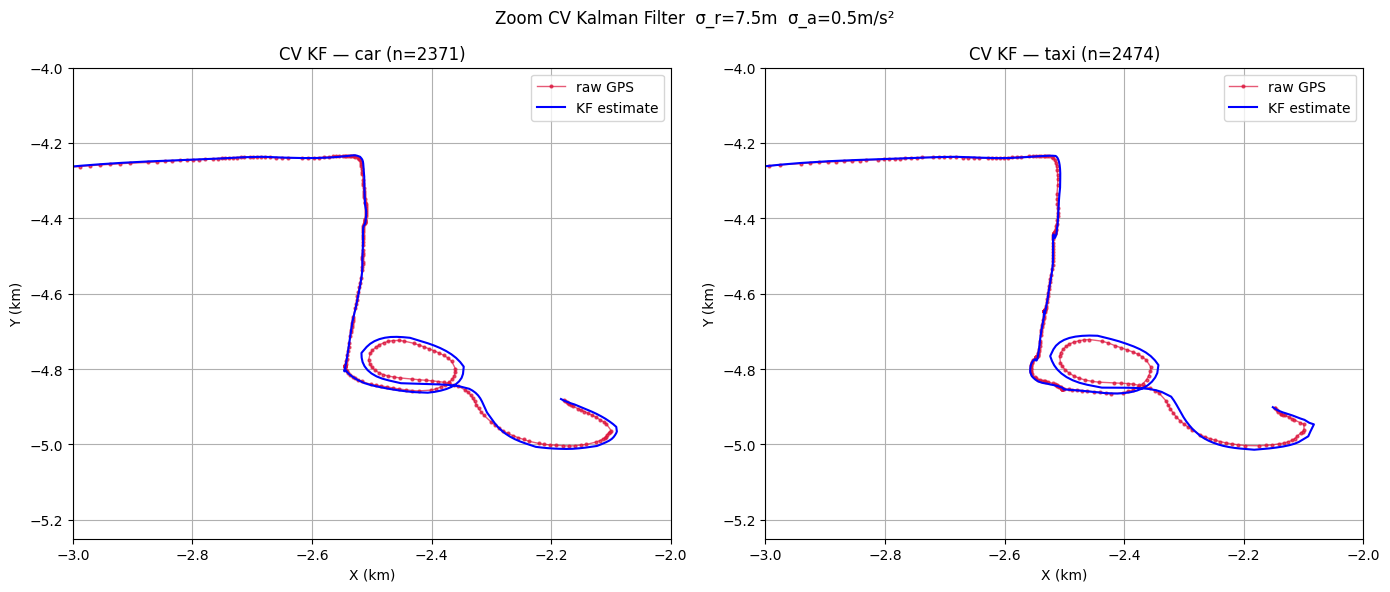

<Figure size 640x480 with 0 Axes>

In [29]:
car_s_ca, car_z_ca   = car_cv_logger.get_stat(["s", "z"])
car_kx_ca, car_ky_ca = extract_xy_from_history(car_s_ca)
car_x_meas_ca, car_y_meas_ca = extract_xy_from_history(car_z_ca)

taxi_s_ca, taxi_z_ca = taxi_cv_logger.get_stat(["s", "z"])
taxi_kx_ca, taxi_ky_ca = extract_xy_from_history(taxi_s_ca)
taxi_x_meas_ca, taxi_y_meas_ca = extract_xy_from_history(taxi_z_ca)

fig_ca, axes_ca = plt.subplots(1, 2, figsize=(14, 6))

zoom = (-3.0,-2.0,-5.25, -4.0)

plot_trajectory(car_x_meas_ca,  car_y_meas_ca,  car_kx_ca,  car_ky_ca,
                title=f"CV KF — {car_seg['mode']} (n={len(car_x_meas_ca)})",
                ax=axes_ca[0],  zoom = zoom)
plot_trajectory(taxi_x_meas_ca, taxi_y_meas_ca, taxi_kx_ca, taxi_ky_ca,
                title=f"CV KF — {taxi_seg['mode']} (n={len(taxi_x_meas_ca)})",
                ax=axes_ca[1],  zoom = zoom)

plt.suptitle("Zoom CV Kalman Filter  σ_r=7.5m  σ_a=0.5m/s²")
plt.tight_layout()
plt.show()


plt.suptitle("Zoom CV Kalman Filter  σ_r=7.5m  σ_a=0.5m/s²")
plt.tight_layout()
plt.show()

#### CV vs CA — single segment comparison

| | acc_raw | acc_kf | improvement | rse_median | rse_p95 |
|--|---------|--------|-------------|------------|---------|
| car CV  | 2.084 | 0.967 | 53.6% | 4.76 m |  19.4 m |
| car CA  | 2.084 | 1.171 | 43.8% | 1.93 m |   7.7 m |
| taxi CV | 1.627 | 0.953 | 41.4% | 4.11 m |  16.3 m |
| taxi CA | 1.627 | 0.978 | 39.9% | 2.11 m |   6.9 m |

The CV model removes more high-frequency jitter (higher acc improvement)
but at the cost of prediction accuracy — the constant-velocity assumption
forces the filter to over-smooth, missing real acceleration events.

The CA model predicts position more accurately (rse_median ~2 m vs ~4.5 m,
p95 ~7 m vs ~18 m) because it explicitly models acceleration. It smooths
less aggressively, but the remaining signal is physically consistent.

**Conclusion:** for urban GPS tracking where prediction accuracy matters,
CA outperforms CV. For pure smoothing, CV is sufficient.

#### Innovation analysis — CV vs CA

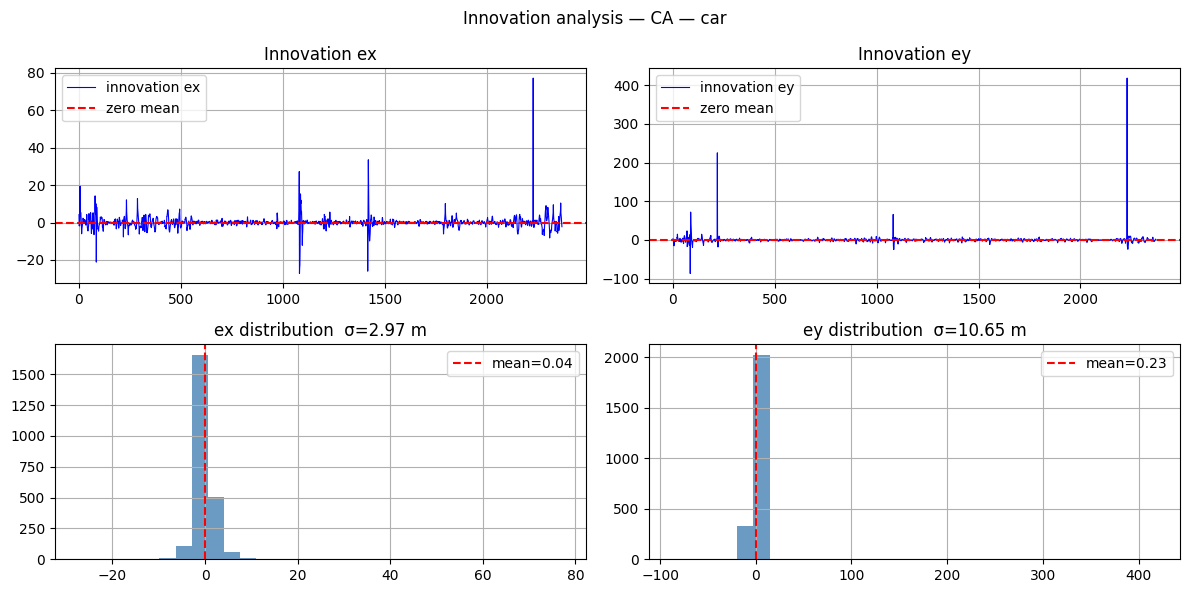

ex: mean=0.037  std=2.969  min=-27.228  max=77.082
ey: mean=0.232  std=10.654  min=-86.525  max=418.054


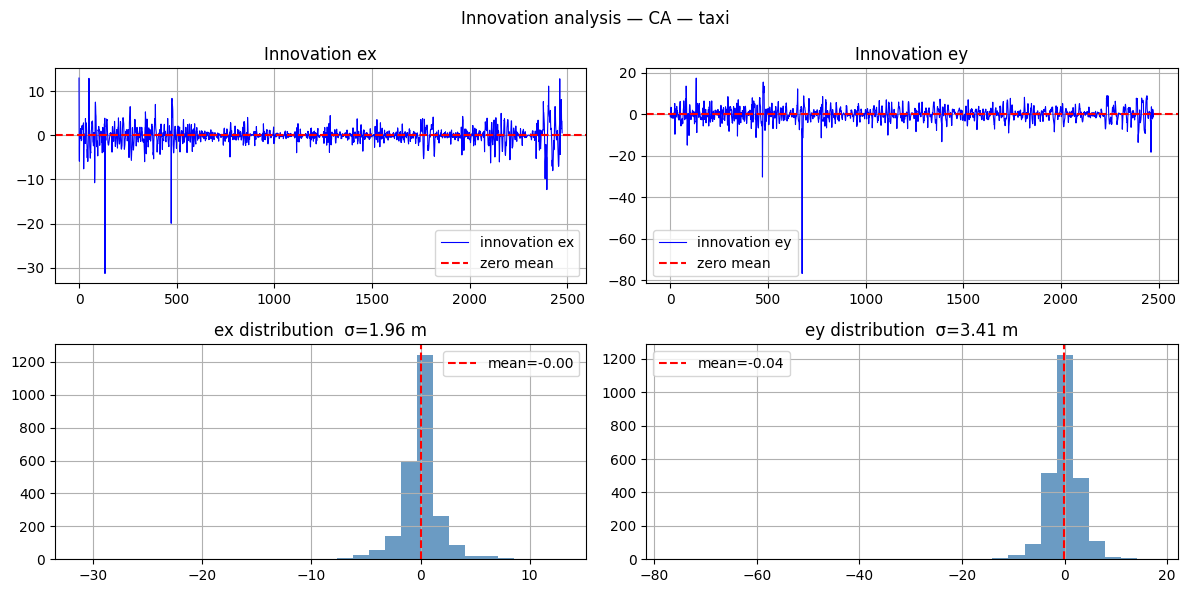

ex: mean=-0.001  std=1.956  min=-31.299  max=12.965
ey: mean=-0.039  std=3.406  min=-76.841  max=17.311


In [30]:
plot_innovations(car_seg, car_ca_logger,  model_name='CA')
plot_innovations(taxi_seg, taxi_ca_logger, model_name='CA')


| | $e_x$ std | $e_y$ std | $e_y$ max |
|--|-----------|-----------|-----------|
| car CV  | 5.54 m |  9.79 m | 287 m |
| car CA  | 2.97 m | 10.65 m | 418 m |
| taxi CV | 4.62 m |  6.71 m |  97 m |
| taxi CA | 1.95 m |  3.41 m |  17 m |

The taxi CA result is strong — $e_y$ std drops from 6.71 to 3.41 m and
the maximum innovation from 97 to 17 m. The CA model captures the taxi
dynamics well, producing near-Gaussian innovations with no systematic trend. ✓

The car CA result is mixed — $e_x$ std improves (5.54 → 2.97 m) but
$e_y$ std slightly worsens (9.79 → 10.65 m) and the maximum grows
(287 → 418 m). Residual GPS jumps below the 500 m outlier threshold
dominate the $e_y$ distribution and inflate all statistics. ✗

Both segments show **mean ≈ 0** for all models — no systematic bias. ✓

The innovation analysis confirms the trajectory metric conclusion:
CA outperforms CV for the taxi segment; for the car segment, outlier
GPS fixes limit the benefit of the more complex model.

#### Parameter tuning — σ_a

In [31]:
for sigma_a in [0.1, 0.5, 1.0, 2.0, 5.0]:
    logger = run_kf_ca(car_seg, sigma_a=sigma_a)
    m = compute_metrics(car_seg, logger, model='ca')
    imp = (1 - m['acc_kf'] / m['acc_raw']) * 100
    print(f"sigma_a={sigma_a:.1f}  acc_imp={imp:.1f}%  rse_med={m['rse_median']:.2f}  rse_p95={m['rse_p95']:.2f}")

sigma_a=0.1  acc_imp=48.4%  rse_med=4.26  rse_p95=17.01
sigma_a=0.5  acc_imp=43.8%  rse_med=1.93  rse_p95=7.71
sigma_a=1.0  acc_imp=38.1%  rse_med=1.41  rse_p95=5.50
sigma_a=2.0  acc_imp=31.6%  rse_med=1.06  rse_p95=4.31
sigma_a=5.0  acc_imp=22.8%  rse_med=0.83  rse_p95=3.26


In [32]:
for sigma_a in [0.1, 0.5, 1.0, 2.0, 5.0]:
    logger = run_kf_ca(taxi_seg, sigma_a=sigma_a)
    m = compute_metrics(taxi_seg, logger, model='ca')
    imp = (1 - m['acc_kf'] / m['acc_raw']) * 100
    print(f"sigma_a={sigma_a:.1f}  acc_imp={imp:.1f}%  rse_med={m['rse_median']:.2f}  rse_p95={m['rse_p95']:.2f}")

sigma_a=0.1  acc_imp=-1.4%  rse_med=3.98  rse_p95=14.18
sigma_a=0.5  acc_imp=39.9%  rse_med=2.11  rse_p95=6.86
sigma_a=1.0  acc_imp=34.3%  rse_med=1.67  rse_p95=5.48
sigma_a=2.0  acc_imp=29.1%  rse_med=1.32  rse_p95=4.87
sigma_a=5.0  acc_imp=20.7%  rse_med=1.08  rse_p95=4.34


The process noise parameter $\sigma_a$ controls the trade-off between smoothing and model flexibility:

- **small σ_a** — filter trusts the motion model strongly; smoother trajectory but may fail to follow sharp turns and stops
- **large σ_a** — filter follows measurements more closely; better prediction accuracy but less smoothing

| $\sigma_a$ | car acc_imp | taxi acc_imp | car rse_med | taxi rse_med |
|------------|-------------|--------------|-------------|--------------|
| 0.1 | 48.4% | -1.5% (-) | 4.26 m | 3.98 m |
| 0.5 | 43.8% | 39.9% (+) | 1.93 m | 2.11 m |
| 1.0 | 38.1% | 34.3% | 1.41 m | 1.67 m |
| 2.0 | 31.6% | 29.1% | 1.06 m | 1.32 m |
| 5.0 | 22.8% | 20.7% | 0.83 m | 1.08 m |

At $\sigma_a = 0.1$ the taxi segment actually **worsens** (-1.5%) — the filter is too rigid to follow real acceleration events in urban driving.

$\sigma_a = 0.5$ gives the best compromise for both segments and is used as the default throughout this analysis.

## Summary — Does the Kalman filter work for GPS smoothing?

**Short answer: yes, but the choice of model matters.**

Both CV and CA filters consistently reduce GPS jitter — acceleration RMS drops by 40-54% on the car segment and 40-43% on the taxi segment. The filtered trajectory is visually smoother, and velocity estimates are physically plausible (~20 km/h for urban Beijing).

CA predicts position more accurately than CV (rse_median ~2 m vs ~4.5 m). because it explicitly models acceleration. However, CV removes more high-frequency noise. The right choice depends on the application: use CA when prediction accuracy matters, CV when smoothness is the goal.

**Is one car and one taxi a good sample?**

No — two segments are a very limited sample. The car segment has residual GPS jumps that distort the statistics, and the taxi segment may not be representative of all driving conditions. Before drawing general conclusions, we need to test on all 91 segments and look at the distribution of results across different routes, times, and driving styles.

The single-segment analysis here serves as a sanity check and parameter validation.

A recent study applying a parameter-free Kalman filter with attention learning (Transformer + LSTM) to the GeoLife Beijing vehicle dataset confirmed that the classical linear Kalman filter serves as a strong baseline for GPS smoothing, while adaptive parameter estimation via neural networks can further improve accuracy in highly manoeuvring scenarios [[PMC, 2023](https://pmc.ncbi.nlm.nih.gov/articles/PMC10610770/)]. Our results are consistent with this finding — the linear CA filter achieves good prediction accuracy (rse_median ~2 m) with manually tuned parameters, leaving room for improvement through adaptive σ_r and σ_a estimation.

## References

**Research in the Field**

[PMC2023] Liu, X. et al., *Parameter-Free State Estimation Based on Kalman
    Filter with Attention Learning for GPS Tracking in Autonomous Driving
    System*, Sensors, 23(20), 8650, 2023.
    https://doi.org/10.3390/s23208650

[TrackToTrip] Gil, R., *TrackToTrip: GPS Track Processing Library*,
    https://github.com/ruipgil/TrackToTrip

[BeijingTraj] Bremner, J., *Beijing Trajectories Project*,
    https://github.com/jbremz/Beijing-Trajectories-Project

[BeijingTraffic] Liu, C., Wang, S., Cuomo, S., Mei, G.,
    *Data Analysis and Mining of Traffic Features Based on Taxi GPS Trajectories:
    A Case Study in Beijing*, Concurrency and Computation: Practice and Experience,
    33(3), e5332, 2021.
    https://doi.org/10.1002/cpe.5332

**Materials and tools used**

[GeoLife] Zheng, Y. et al., *GeoLife GPS Trajectory Dataset — User Guide*,
    Microsoft Research Asia, 2012.
    https://www.microsoft.com/en-us/research/publication/geolife-gps-trajectory-dataset-user-guide/

[WelchBishop] Welch, G. and Bishop, G., *An Introduction to the Kalman Filter*,
    University of North Carolina, 2006.
    https://www.cs.unc.edu/~welch/media/pdf/kalman_intro.pdf

[KalmanFilterNet] Becker, A., *Kalman Filter from the Ground Up*,
    https://kalmanfilter.net/kalmanfilter.html

[Bzarg] Bzarg, *How a Kalman Filter Works, in Pictures*, 2015.
    https://www.bzarg.com/p/how-a-kalman-filter-works-in-pictures/

[FilterPy] Labbe, R., *FilterPy — Kalman Filters in Python*,
    https://filterpy.readthedocs.io/en/latest/

[RWTH-CV2] RWTH Aachen, *Computer Vision II — Lecture Notes*,
    https://www.vision.rwth-aachen.de/

[WikipediaKF] Wikipedia, *Kalman Filter*,
    https://en.wikipedia.org/wiki/Kalman_filter

[BilginEsme] Bilgin, E., *Kalman Filter for Beginners*,
    https://github.com/bilginEsme

[MovableType] Movable Type Scripts, *Calculate Distance and Bearing*,
    https://www.movable-type.co.uk/scripts/latlong.html